## Load dataframe containing information about the templates, inclusing metric scores

In [1]:
import pandas as pd
metrics = pd.read_csv('/home/augusta/storage3/augusta/insituCNV/InSituCNV/Evaluate_technical_constrains/results/metrics/metrics_master.csv')

### Generate overview of downsampling

/tmp/ipykernel_2203296/108371278.py:50: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_labels = counts_table.applymap(lambda x: "" if pd.isna(x) else f"{x:.0f}")


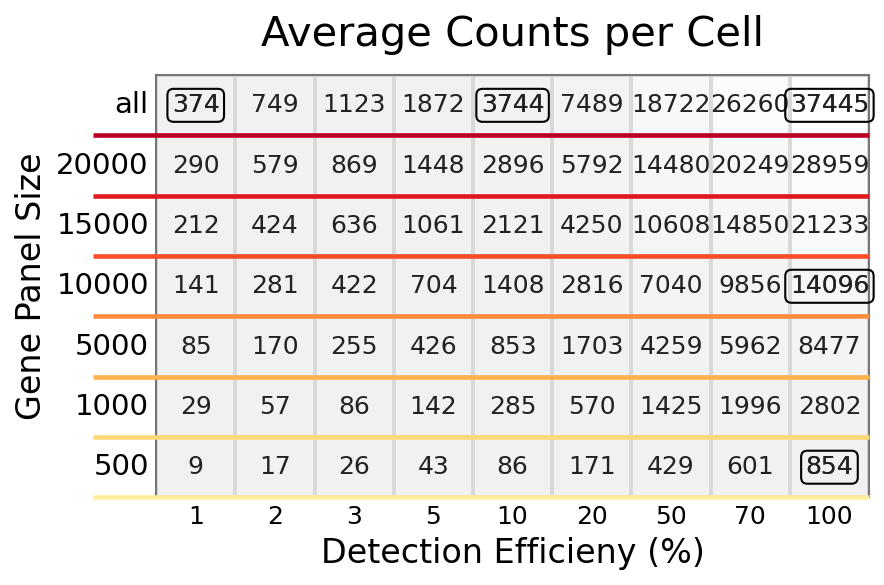

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ---------------------------
# Settings
# ---------------------------
OUT_DIR = Path("heatmaps_metric_means")
OUT_DIR.mkdir(exist_ok=True)

df = metrics.copy()
df["gene_panel"] = df["gene_panel"].astype(str)
df["count_fraction"] = pd.to_numeric(df["count_fraction"], errors="coerce")
df["mean_countsxcell"] = pd.to_numeric(df["mean_countsxcell"], errors="coerce")

# Desired order
gene_order = ["500", "1000", "5000", "10000", "15000", "20000", "all"]
count_order = [1, 2, 3, 5, 10, 20, 50, 70, 100]

# ---------------------------
# Aggregate across templates
# ---------------------------
agg = (
    df.groupby(["gene_panel", "count_fraction"], observed=False)
    .agg(mean_countsxcell=("mean_countsxcell", "mean"))
    .reset_index()
)

# ---------------------------
# Build table
# rows = gene_panel
# cols = count_fraction
# ---------------------------
counts_table = agg.pivot_table(
    index="gene_panel",
    columns="count_fraction",
    values="mean_countsxcell",
    aggfunc="mean",
)

rows_present = [g for g in gene_order if g in counts_table.index]
cols_present = [c for c in count_order if c in counts_table.columns]
counts_table = counts_table.loc[rows_present, cols_present]

# reverse so bottom->top is 500->all
counts_table = counts_table.iloc[::-1]

# integer labels
annot_labels = counts_table.applymap(lambda x: "" if pd.isna(x) else f"{x:.0f}")

# ---------------------------
# Figure
# ---------------------------
fig, ax = plt.subplots(figsize=(6, 4), dpi=150)


# very faint heatmap base just to keep grid geometry
sns.heatmap(
    counts_table,
    ax=ax,
    cmap=sns.light_palette("#ffffff", as_cmap=True),
    cbar=False,
    annot=False,
    linewidths=1.0,
    linecolor="#d9d9d9",
)

# ---------------------------
# Colored horizontal row lines
# ---------------------------
# bottom row (500) orange-ish -> top row (all) red-ish
row_colors = sns.color_palette("YlOrRd", n_colors=len(counts_table.index))[::-1]


nrows, ncols = counts_table.shape

for i, color in enumerate(row_colors):
    y = i + 1
    ax.hlines(
        y=y,
        xmin=-0.8,
        xmax=ncols,
        colors=[color],
        linewidth=2.2,
        clip_on=False,
        zorder=3,
    )

# ---------------------------
# Cell text
# ---------------------------
for i in range(nrows):
    for j in range(ncols):
        val = annot_labels.iloc[i, j]
        if val != "":
            ax.text(
                j + 0.5,
                i + 0.5,
                val,
                ha="center",
                va="center",
                fontsize=12,
                color="#222222",
                zorder=4,
            )

# Optional: box a few cells like in your example
# give coordinates as (row_label, col_label)
boxed_cells = [
    ("all", 1),
    ("all", 10),
    #("10000", 10),
    ("all", 100),
    ("10000", 100),
    ("500", 100),
]

# because table is reversed for plotting
row_lookup = {label: idx for idx, label in enumerate(counts_table.index)}
col_lookup = {label: idx for idx, label in enumerate(counts_table.columns)}

for rlab, clab in boxed_cells:
    if rlab in row_lookup and clab in col_lookup:
        i = row_lookup[rlab]
        j = col_lookup[clab]
        ax.text(
            j + 0.5,
            i + 0.5,
            annot_labels.loc[rlab, clab],
            ha="center",
            va="center",
            fontsize=12,
            color="#222222",
            bbox=dict(
                boxstyle="round,pad=0.18,rounding_size=0.25",
                facecolor="none",
                edgecolor="Black",
                linewidth=1.0,
            ),
            zorder=5,
        )

# ---------------------------
# Labels and title
# ---------------------------
ax.set_title("Average Counts per Cell", fontsize=20, pad=14)
ax.set_xlabel("Detection Efficieny (%)",fontsize=16)
ax.set_ylabel("Gene Panel Size", fontsize=16)

ax.set_xticklabels([str(x) for x in counts_table.columns], fontsize=12)
ax.set_yticklabels([str(y) for y in counts_table.index], fontsize=14, rotation=0)

# remove tick marks
ax.tick_params(axis="both", length=0)

# frame styling
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.0)
    spine.set_edgecolor("#777777")

plt.tight_layout()

fig.savefig(
    OUT_DIR / "average_counts_per_cell_styled.pdf",
    dpi=220,
    bbox_inches="tight",
    facecolor=fig.get_facecolor(),
)
plt.show()

In [29]:
from matplotlib.colors import LinearSegmentedColormap
white_yellow_cmap = LinearSegmentedColormap.from_list(
    "white_yellow",
    ["#ffffff", "#6db66a"]
)

In [2]:
metrics

,run_id,template_id,count_fraction,gene_panel,n_genes,mean_countsxcell,nmi,ari,F1_all,F1_gain,F1_loss,AUC_gains,PR_gains,AUC_loss,PR_loss
0,T01_C1_G1000,T01,1,1000,1000,28.032335,0.010155,0.010352,0.076275,0.159449,0.000000,0.527417,0.006067,0.510551,0.010201
1,T01_C1_G10000,T01,1,10000,10000,138.865936,0.180122,0.174528,0.247986,0.543705,0.000000,0.667095,0.046968,0.535073,0.012831
2,T01_C1_G15000,T01,1,15000,15000,210.013412,0.277569,0.325056,0.324697,0.663805,0.008886,0.739497,0.111861,0.535388,0.012728
3,T01_C1_G20000,T01,1,20000,20000,287.126190,0.300779,0.317375,0.326175,0.669319,0.012545,0.745061,0.133093,0.534232,0.012769
4,T01_C1_G500,T01,1,500,500,8.569401,0.001510,-0.002626,0.033841,0.045516,0.000000,0.500257,0.007601,0.505290,0.010525
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
619,T10_C100_G15000,T10,100,15000,15000,21454.380859,0.992235,0.995843,0.831058,0.791661,0.856464,0.838815,0.594577,0.885221,0.661043
620,T10_C100_G20000,T10,100,20000,20000,29297.142578,0.996146,0.998041,0.862069,0.833142,0.880234,0.867642,0.662990,0.902952,0.711900
621,T10_C100_G500,T10,100,500,500,859.024048,0.257471,0.204134,0.185289,0.315910,0.097321,0.593185,0.102279,0.529059,0.032886
622,T10_C100_G5000,T10,100,5000,5000,8663.318359,0.962612,0.972348,0.705356,0.699486,0.708321,0.780554,0.446961,0.785466,0.387021


In [ ]:
metrics[

In [3]:
tables = {}

for template, sub in metrics.groupby("template_id"):
    table = sub.pivot_table(
        index="count_fraction",
        columns="gene_panel",
        values="mean_countsxcell",
        aggfunc="mean"
    ).sort_index()

    tables[template] = table

In [4]:
tables["T01"]  # example

gene_panel,1000,10000,15000,20000,500,5000,all
count_fraction,,,,,,,
1,28.032335,138.865936,210.013412,287.126190,8.569401,83.883278,372.791809
2,55.941639,277.130127,419.763397,573.857239,17.056782,167.202682,745.583618
3,84.073341,415.918762,630.168762,860.871460,25.476341,251.007095,1118.375366
5,140.058365,694.612793,1051.728760,1435.851685,42.574921,419.191650,1863.958984
10,280.145111,1389.260986,2103.626221,2871.137207,85.007889,837.616699,3727.917969
20,559.964539,2779.569336,4208.324219,5741.500000,170.738174,1674.301270,7455.836914
50,1402.652954,6951.474121,10523.248047,14354.753906,426.132507,4189.043945,18639.591797
70,1963.951050,9729.751953,14730.602539,20096.392578,596.091492,5864.283203,26095.429688
100,2756.833984,13920.518555,21065.599609,28713.398438,847.242310,8341.425781,37279.179688


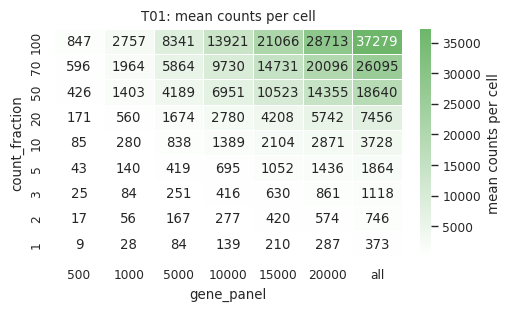

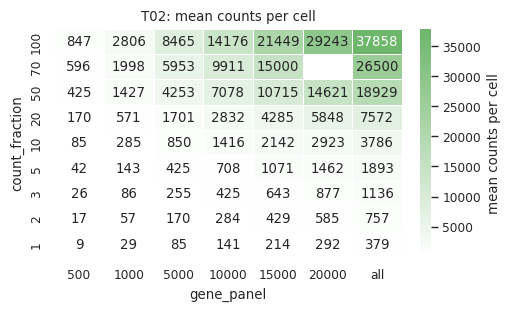

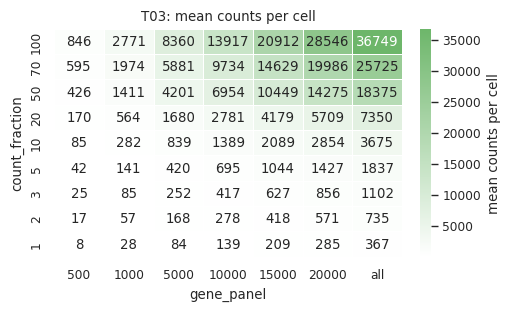

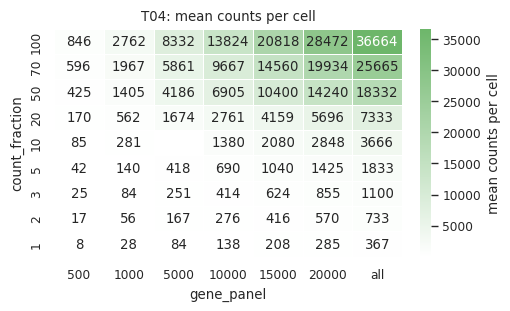

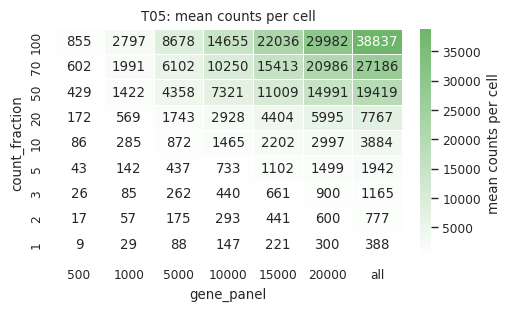

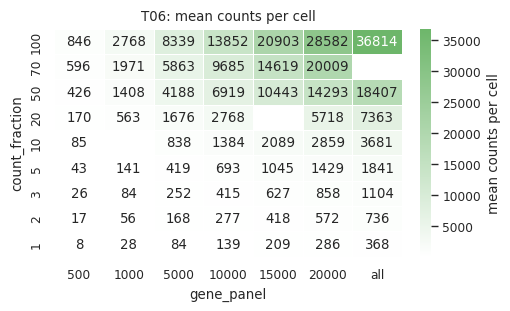

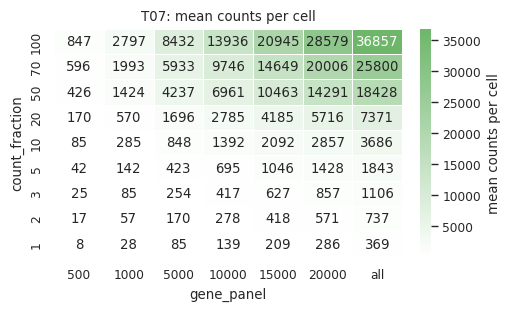

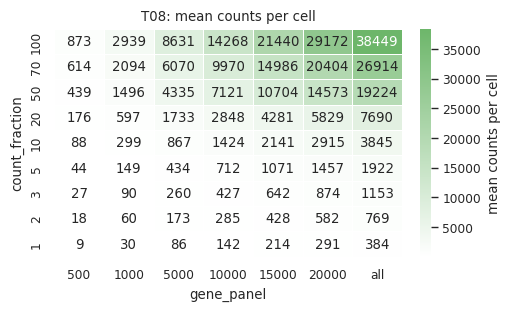

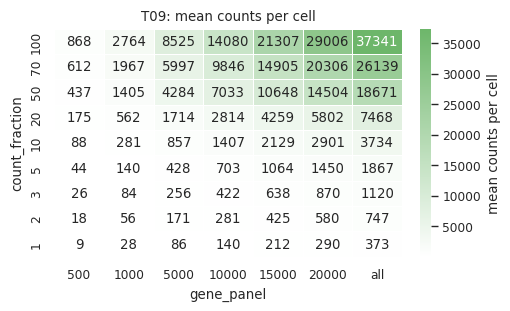

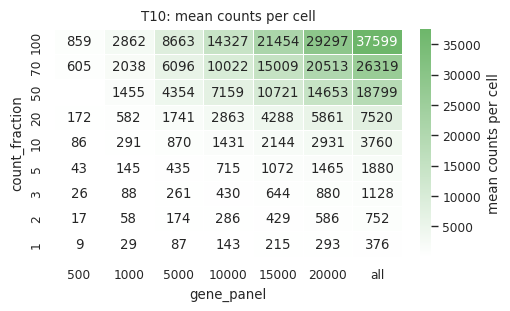

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Output folder
HEATMAP_DIR = Path("heatmaps_countsxcell")
HEATMAP_DIR.mkdir(exist_ok=True)

# Make sure gene_panel is string so numeric panels + 'all' can coexist
metrics = metrics.copy()
metrics["gene_panel"] = metrics["gene_panel"].astype(str)

# Optional: define a sensible column order
gene_order = sorted(
    metrics["gene_panel"].unique(),
    key=lambda x: float(x) if x != "all" else float("inf")
)

sns.set_style("white")
sns.set_context("paper")

for template, sub in metrics.groupby("template_id"):
    table = sub.pivot_table(
        index="count_fraction",
        columns="gene_panel",
        values="mean_countsxcell",
        aggfunc="mean"
    )

    # Reorder columns if present
    cols_present = [g for g in gene_order if g in table.columns]
    table = table[cols_present]

    # Sort count_fraction numerically
    table = table.sort_index(ascending=False)

    fig, ax = plt.subplots(figsize=(5, 3), constrained_layout=True)

    sns.heatmap(
        table,
        ax=ax,
        cmap=white_yellow_cmap,#"YlOrRd",
        annot=True,
        fmt=".0f",
        linewidths=0.5,
        cbar_kws={"label": "mean counts per cell"}
    )

    ax.set_title(f"{template}: mean counts per cell")
    ax.set_xlabel("gene_panel")
    ax.set_ylabel("count_fraction")

    fig.savefig(HEATMAP_DIR / f"heatmap_countsxcell_{template}.png", dpi=220)
    plt.show()

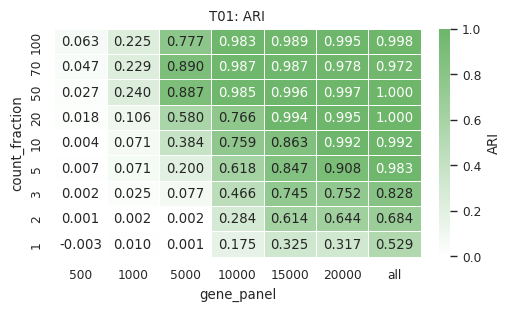

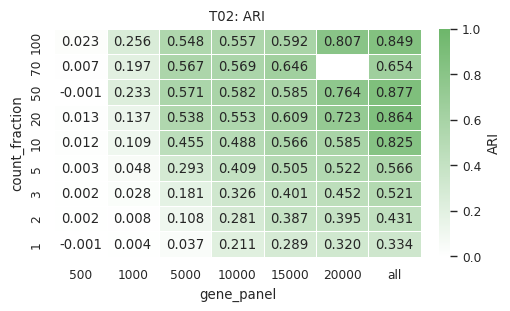

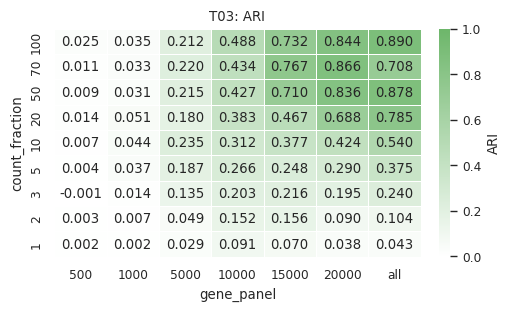

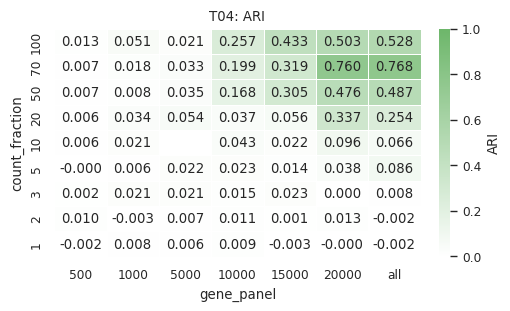

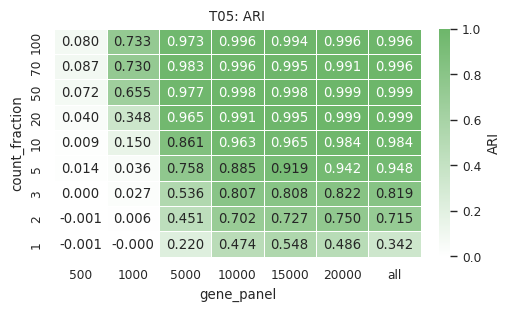

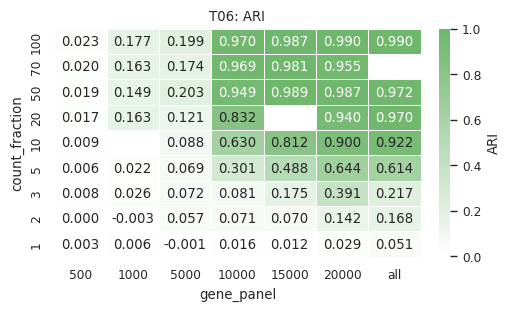

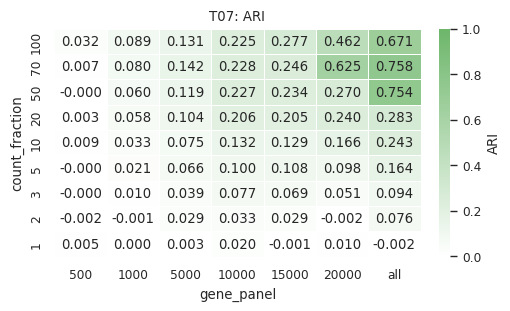

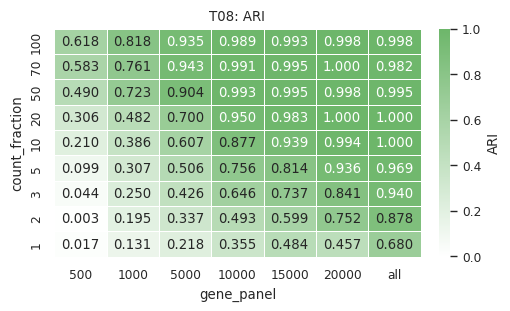

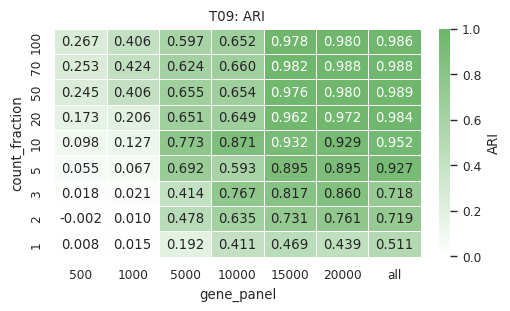

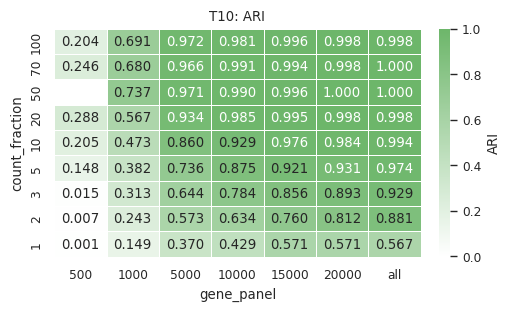

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path



# Output folder
HEATMAP_DIR = Path("heatmaps_ari")
HEATMAP_DIR.mkdir(exist_ok=True)

# Work on a copy
df = metrics.copy()

# Make types consistent
df["gene_panel"] = df["gene_panel"].astype(str)
df["count_fraction"] = pd.to_numeric(df["count_fraction"], errors="coerce")
df["ari"] = pd.to_numeric(df["ari"], errors="coerce")

# Optional ordering for gene_panel
gene_order = sorted(
    df["gene_panel"].dropna().unique(),
    key=lambda x: float(x) if x != "all" else float("inf")
)

sns.set_style("white")
sns.set_context("paper")

for template, sub in df.groupby("template_id"):
    table = sub.pivot_table(
        index="count_fraction",
        columns="gene_panel",
        values="ari",
        aggfunc="mean"
    )

    # Reorder rows and columns
    table = table.sort_index(ascending=False)
    cols_present = [g for g in gene_order if g in table.columns]
    table = table[cols_present]

    fig, ax = plt.subplots(figsize=(5, 3), constrained_layout=True)

    sns.heatmap(
        table,
        ax=ax,
        cmap=white_yellow_cmap,#"YlOrRd",
        annot=True,
        fmt=".3f",
        linewidths=0.5,
        vmin=df["ari"].min(),
        vmax=df["ari"].max(),
        cbar_kws={"label": "ARI"}
    )

    ax.set_title(f"{template}: ARI")
    ax.set_xlabel("gene_panel")
    ax.set_ylabel("count_fraction")

    fig.savefig(HEATMAP_DIR / f"heatmap_ari_{template}.pdf", dpi=220, bbox_inches="tight")
    plt.show()

/tmp/ipykernel_2197727/2672445645.py:51: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_labels = annot_table.applymap(


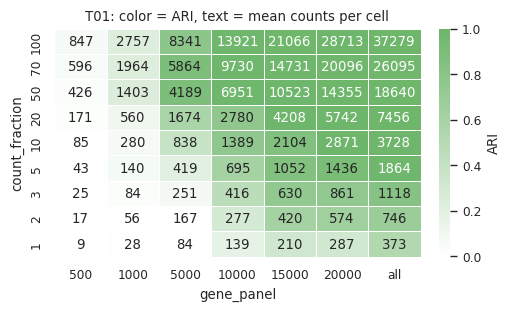

/tmp/ipykernel_2197727/2672445645.py:51: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_labels = annot_table.applymap(


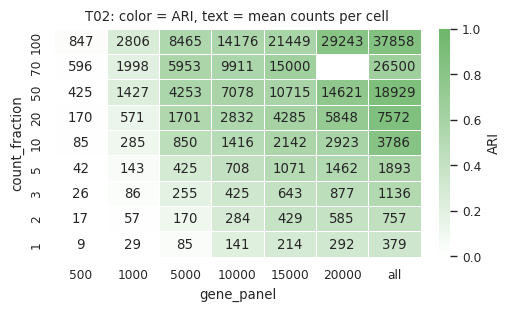

/tmp/ipykernel_2197727/2672445645.py:51: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_labels = annot_table.applymap(


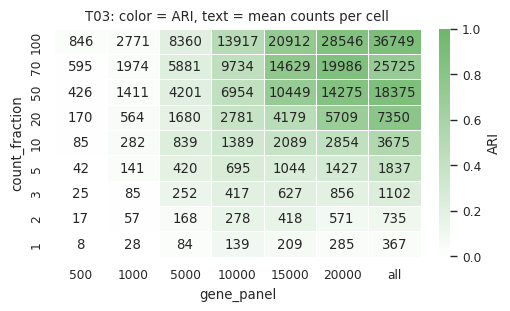

/tmp/ipykernel_2197727/2672445645.py:51: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_labels = annot_table.applymap(


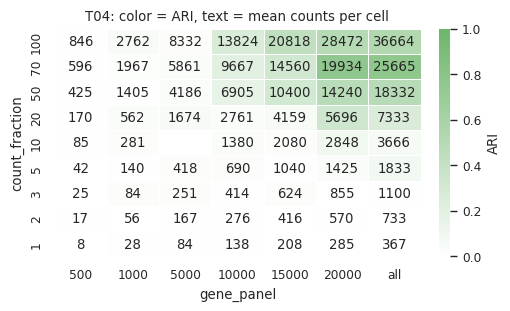

/tmp/ipykernel_2197727/2672445645.py:51: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_labels = annot_table.applymap(


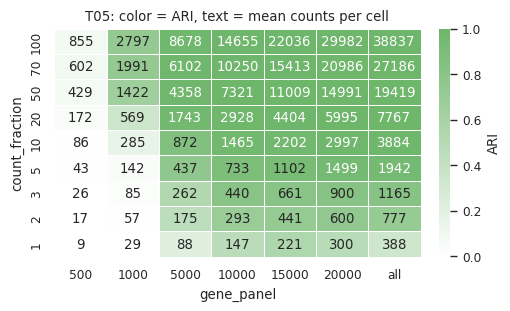

/tmp/ipykernel_2197727/2672445645.py:51: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_labels = annot_table.applymap(


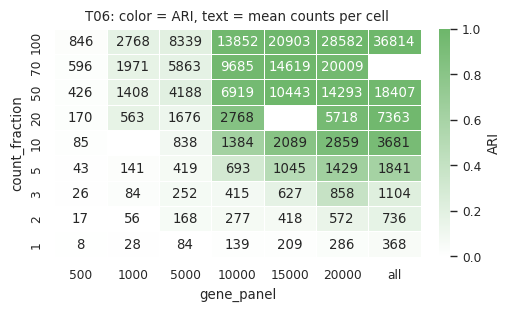

/tmp/ipykernel_2197727/2672445645.py:51: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_labels = annot_table.applymap(


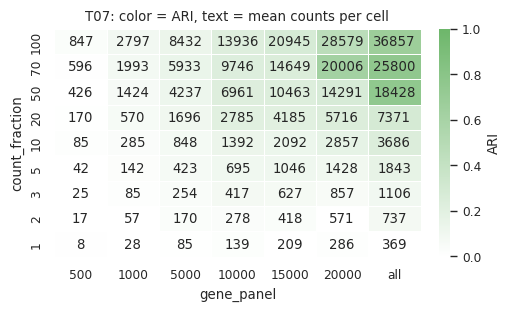

/tmp/ipykernel_2197727/2672445645.py:51: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_labels = annot_table.applymap(


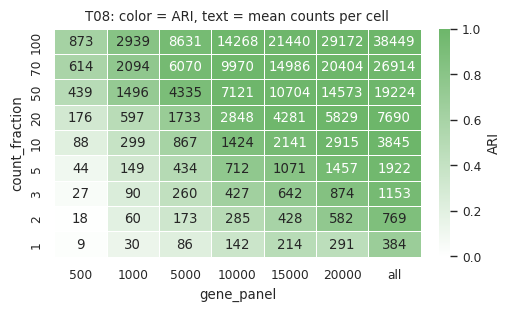

/tmp/ipykernel_2197727/2672445645.py:51: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_labels = annot_table.applymap(


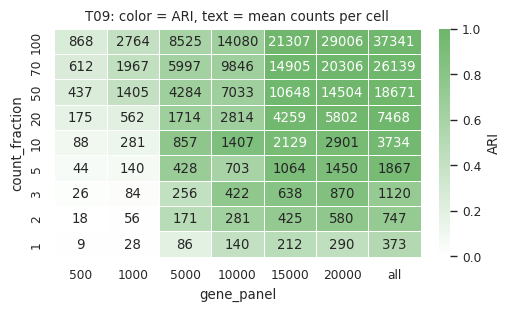

/tmp/ipykernel_2197727/2672445645.py:51: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_labels = annot_table.applymap(


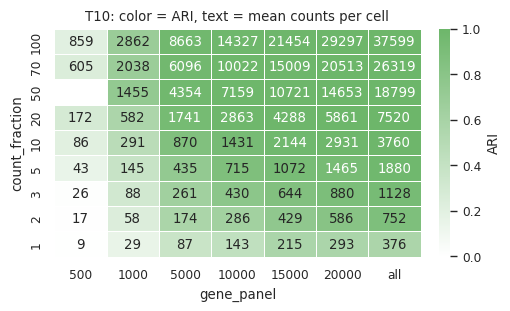

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

HEATMAP_DIR = Path("heatmaps_ari_with_counts")
HEATMAP_DIR.mkdir(exist_ok=True)

df = metrics.copy()
df["gene_panel"] = df["gene_panel"].astype(str)
df["count_fraction"] = pd.to_numeric(df["count_fraction"], errors="coerce")
df["ari"] = pd.to_numeric(df["ari"], errors="coerce")
df["mean_countsxcell"] = pd.to_numeric(df["mean_countsxcell"], errors="coerce")

gene_order = sorted(
    df["gene_panel"].dropna().unique(),
    key=lambda x: float(x) if x != "all" else float("inf")
)

sns.set_style("white")
sns.set_context("paper")

global_vmin = df["ari"].min()
global_vmax = df["ari"].max()

for template, sub in df.groupby("template_id"):
    ari_table = sub.pivot_table(
        index="count_fraction",
        columns="gene_panel",
        values="ari",
        aggfunc="mean"
    )

    counts_table = sub.pivot_table(
        index="count_fraction",
        columns="gene_panel",
        values="mean_countsxcell",
        aggfunc="mean"
    )

    ari_table = ari_table.sort_index(ascending=False)
    counts_table = counts_table.sort_index(ascending=False)

    cols_present = [g for g in gene_order if g in ari_table.columns]
    ari_table = ari_table[cols_present]
    counts_table = counts_table[cols_present]

    annot_table = counts_table.copy()

    # Choose number format for cell labels
    annot_labels = annot_table.applymap(
        lambda x: "" if pd.isna(x) else f"{x:.0f}"
    )

    fig, ax = plt.subplots(figsize=(5, 3), constrained_layout=True)

    sns.heatmap(
        ari_table,
        ax=ax,
        cmap=white_yellow_cmap,
        annot=annot_labels,
        fmt="",
        linewidths=0.5,
        vmin=global_vmin,
        vmax=global_vmax,
        cbar_kws={"label": "ARI"}
    )

    ax.set_title(f"{template}: color = ARI, text = mean counts per cell")
    ax.set_xlabel("gene_panel")
    ax.set_ylabel("count_fraction")

    fig.savefig(
        HEATMAP_DIR / f"heatmap_ari_with_counts_{template}.pdf",
        dpi=220,
        bbox_inches="tight"
    )
    plt.show()

/tmp/ipykernel_2197727/1728330103.py:33: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_labels = counts_table.applymap(


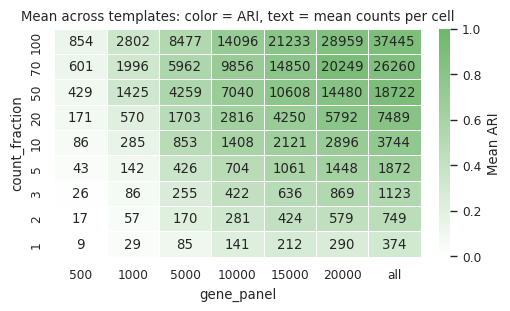

In [20]:
# --- Aggregate across templates ---
agg = (
    df.groupby(["count_fraction", "gene_panel"], observed=False)
    .agg(
        ari=("ari", "mean"),
        mean_countsxcell=("mean_countsxcell", "mean"),
    )
    .reset_index()
)

# --- Create tables ---
ari_table = agg.pivot_table(
    index="count_fraction",
    columns="gene_panel",
    values="ari"
)

counts_table = agg.pivot_table(
    index="count_fraction",
    columns="gene_panel",
    values="mean_countsxcell"
)

# --- Sort and align ---
ari_table = ari_table.sort_index(ascending=False)
counts_table = counts_table.sort_index(ascending=False)

cols_present = [g for g in gene_order if g in ari_table.columns]
ari_table = ari_table[cols_present]
counts_table = counts_table[cols_present]

# --- Annotation (counts as integers) ---
annot_labels = counts_table.applymap(
    lambda x: "" if pd.isna(x) else f"{x:.0f}"
)

# --- Plot ---
fig, ax = plt.subplots(figsize=(5, 3), constrained_layout=True)

sns.heatmap(
    ari_table,
    ax=ax,
    cmap=white_yellow_cmap,   # your custom cmap
    annot=annot_labels,
    fmt="",
    linewidths=0.5,
    vmin=global_vmin,
    vmax=global_vmax,
    cbar_kws={"label": "Mean ARI"}
)

ax.set_title("Mean across templates: color = ARI, text = mean counts per cell")
ax.set_xlabel("gene_panel")
ax.set_ylabel("count_fraction")

fig.savefig(
    HEATMAP_DIR / "heatmap_ari_MEAN.pdf",
    dpi=220,
    bbox_inches="tight"
)

plt.show()

/tmp/ipykernel_2197727/3106847075.py:61: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_labels = counts_table.applymap(


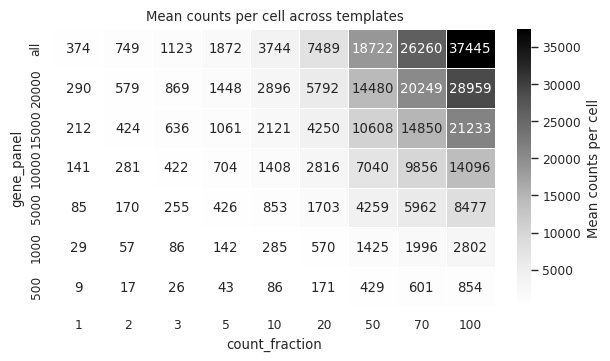

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ---------------------------
# Settings
# ---------------------------
HEATMAP_DIR = Path("heatmaps_metric_means")
HEATMAP_DIR.mkdir(exist_ok=True)

sns.set_style("white")
sns.set_context("paper")

# ---------------------------
# Prepare dataframe
# ---------------------------
df = metrics.copy()

df["gene_panel"] = df["gene_panel"].astype(str)
df["count_fraction"] = pd.to_numeric(df["count_fraction"], errors="coerce")
df["mean_countsxcell"] = pd.to_numeric(df["mean_countsxcell"], errors="coerce")

# Explicit ordering
gene_order = ["500", "1000", "5000", "10000", "15000", "20000", "all"]
count_order = [1, 2, 3, 5, 10, 20, 50, 70, 100]

# ---------------------------
# Aggregate across templates
# ---------------------------
agg = (
    df.groupby(["gene_panel", "count_fraction"], observed=False)
    .agg(mean_countsxcell=("mean_countsxcell", "mean"))
    .reset_index()
)

# ---------------------------
# Build table
# rows = gene_panel
# cols = count_fraction
# ---------------------------
counts_table = agg.pivot_table(
    index="gene_panel",
    columns="count_fraction",
    values="mean_countsxcell",
    aggfunc="mean",
)

# Keep only desired order if present
rows_present = [g for g in gene_order if g in counts_table.index]
cols_present = [c for c in count_order if c in counts_table.columns]

counts_table = counts_table.loc[rows_present, cols_present]

# Reverse row order so the plot shows:
# bottom -> top = 500 -> all
# (heatmap draws first row at the top)
counts_table = counts_table.iloc[::-1]

# Integer labels with no decimals
annot_labels = counts_table.applymap(
    lambda x: "" if pd.isna(x) else f"{x:.0f}"
)

# ---------------------------
# Plot
# ---------------------------
fig, ax = plt.subplots(figsize=(6, 3.5), constrained_layout=True)

sns.heatmap(
    counts_table,
    ax=ax,
    cmap="Greys",#white_yellow_cmap,#"Greens",
    annot=annot_labels,
    fmt="",
    linewidths=0.5,
    cbar_kws={"label": "Mean counts per cell"},
)

ax.set_title("Mean counts per cell across templates")
ax.set_xlabel("count_fraction")
ax.set_ylabel("gene_panel")

fig.savefig(
    HEATMAP_DIR / "heatmap_mean_countsxcell_MEAN_transposed.pdf",
    dpi=220,
    bbox_inches="tight",
)

plt.show()

In [40]:
row_colors

[(0.9999846212995002, 0.9291041906958862, 0.6268050749711649),
 (0.996078431372549, 0.8497808535178777, 0.46145328719723183),
 (0.9960322952710496, 0.6963321799307958, 0.29730103806228375),
 (0.9920953479430988, 0.5490657439446367, 0.23418685121107266),
 (0.9863129565551711, 0.30188389081122646, 0.16362937331795463),
 (0.8866897347174163, 0.09956170703575548, 0.11072664359861592),
 (0.7346097654748174, 0.0, 0.14901960784313725)]